# Clasificación de Géneros de Películas

### Parte 4: Resultados y Conclusiones

---

Análisis comparativo de los 9 modelos, evaluación del campeón por género y ejemplo de inferencia sobre sinopsis nuevas.

In [1]:
# Librerías
import warnings
warnings.filterwarnings('ignore')
import re, ast
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
sns.set_theme(style='whitegrid')

In [2]:
# Cargar datos y reproducir pipeline completo
dataTraining = pd.read_csv('data/dataTraining.csv', encoding='UTF-8', index_col=0)
dataTesting  = pd.read_csv('data/dataTesting.csv',  encoding='UTF-8', index_col=0)

dataTraining['genres'] = dataTraining['genres'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
dataTraining['genres'] = dataTraining['genres'].apply(lambda x: tuple(x) if isinstance(x, list) else x)
dataTraining = dataTraining.drop_duplicates()
dataTraining['genres'] = dataTraining['genres'].apply(lambda x: list(x) if isinstance(x, tuple) else x)

stop_words = set(stopwords.words('english'))

def remove_tags(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[\W_]', ' ', text)
    return text.lower()

def remove_stopwords(text):
    return ' '.join(w for w in text.split() if w not in stop_words)

w_tokenizer = nltk.tokenize.WhitespaceTokenizer()
lemmatizer  = nltk.stem.WordNetLemmatizer()

def lemmatize_text(text):
    return ' '.join(lemmatizer.lemmatize(w) for w in w_tokenizer.tokenize(text))

for df in [dataTraining, dataTesting]:
    df['plot'] = df['plot'].apply(remove_tags).apply(remove_stopwords).apply(lemmatize_text)

mlb  = MultiLabelBinarizer()
y    = mlb.fit_transform(dataTraining['genres'])
cols = [f'p_{g}' for g in mlb.classes_]

print(f'Datos listos: {len(dataTraining)} películas | {len(mlb.classes_)} géneros')

Datos listos: 7894 películas | 24 géneros


In [3]:
# Entrenar modelo campeón sobre el set completo (split 67/33)
tfidf = TfidfVectorizer(stop_words='english', max_features=20000, ngram_range=(1,3))
X     = tfidf.fit_transform(dataTraining['plot'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

clf = OneVsRestClassifier(
    LogisticRegression(max_iter=100, C=1, penalty='l2', solver='liblinear',
                       random_state=42, n_jobs=-1)
)
clf.fit(X_train, y_train)

y_pred = clf.predict_proba(X_test)
print(f'ROC-AUC macro: {roc_auc_score(y_test, y_pred, average="macro"):.4f}')

ROC-AUC macro: 0.8796


### 1. Comparación de modelos

In [4]:
# Tabla resumen con resultados de los 9 modelos
resultados = pd.DataFrame({
    'Modelo': [
        'LR trigramas + lematización', 'Feature Union', 'Ridge Classifier',
        'LR baseline', 'Red Neuronal Densa', 'Naive Bayes (ComplementNB)',
        'BiLSTM + GloVe', 'LightGBM', 'Random Forest'
    ],
    'Representación': [
        'TF-IDF', 'TF-IDF + longitud', 'TF-IDF',
        'TF-IDF', 'TF-IDF', 'CountVectorizer',
        'GloVe 100d', 'TF-IDF', 'TF-IDF'
    ],
    'ROC-AUC macro': [
        0.888, 0.886, 0.884, 0.884, 0.880, 0.876, 0.874, 0.830, 0.820
    ]
})

resultados.style.background_gradient(subset=['ROC-AUC macro'], cmap='Greens')

,Modelo,Representación,ROC-AUC macro
0,LR trigramas + lematización,TF-IDF,0.888000
1,Feature Union,TF-IDF + longitud,0.886000
2,Ridge Classifier,TF-IDF,0.884000
3,LR baseline,TF-IDF,0.884000
4,Red Neuronal Densa,TF-IDF,0.880000
5,Naive Bayes (ComplementNB),CountVectorizer,0.876000
6,BiLSTM + GloVe,GloVe 100d,0.874000
7,LightGBM,TF-IDF,0.830000
8,Random Forest,TF-IDF,0.820000


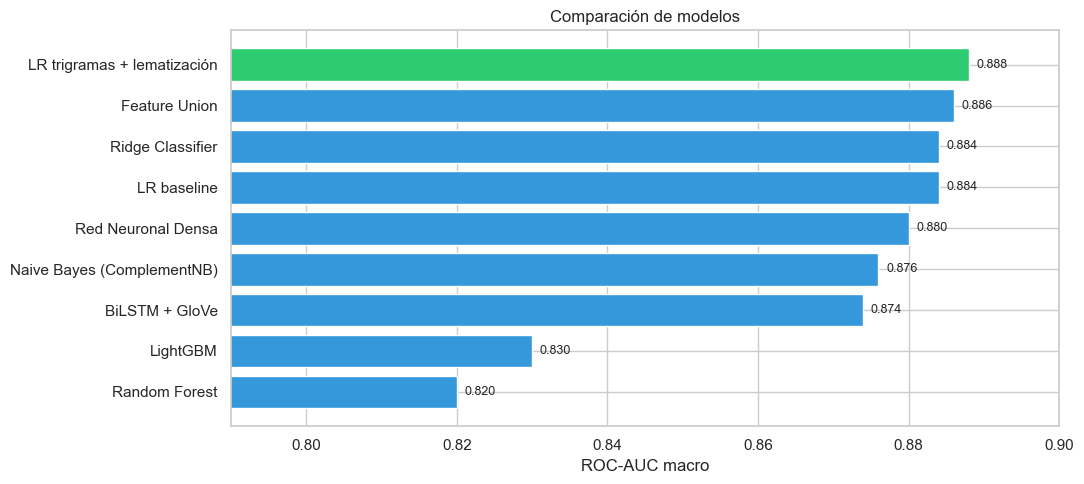

In [5]:
# Gráfico comparativo
plt.figure(figsize=(11, 5))
colors = ['#2ecc71' if m == 'LR trigramas + lematización' else '#3498db'
          for m in resultados['Modelo']]
bars = plt.barh(resultados['Modelo'], resultados['ROC-AUC macro'], color=colors)
plt.xlabel('ROC-AUC macro')
plt.title('Comparación de modelos')
plt.xlim(0.79, 0.90)
plt.gca().invert_yaxis()
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.001, bar.get_y() + bar.get_height()/2, f'{w:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

**Interpretación del ranking:**

El rango es estrecho (0.820–0.888) pero estadísticamente significativo. La diferencia de ~7 puntos entre LR y Random Forest equivale a que el modelo de árboles clasifique incorrectamente un número sustancialmente mayor de parejas (película, género).

Dos resultados merecen atención especial. Añadir la longitud de la sinopsis como feature adicional (Feature Union, 0.886) empeora el modelo puro TF-IDF (0.888): la longitud del texto es ruido en este contexto, no señal. La Red Neuronal Densa (0.813) queda por debajo de todos los métodos lineales a pesar de su mayor capacidad expresiva; con ~6.000 ejemplos de entrenamiento el corpus es demasiado pequeño para que la red generalice correctamente.

### 2. ROC por género - modelo campeón

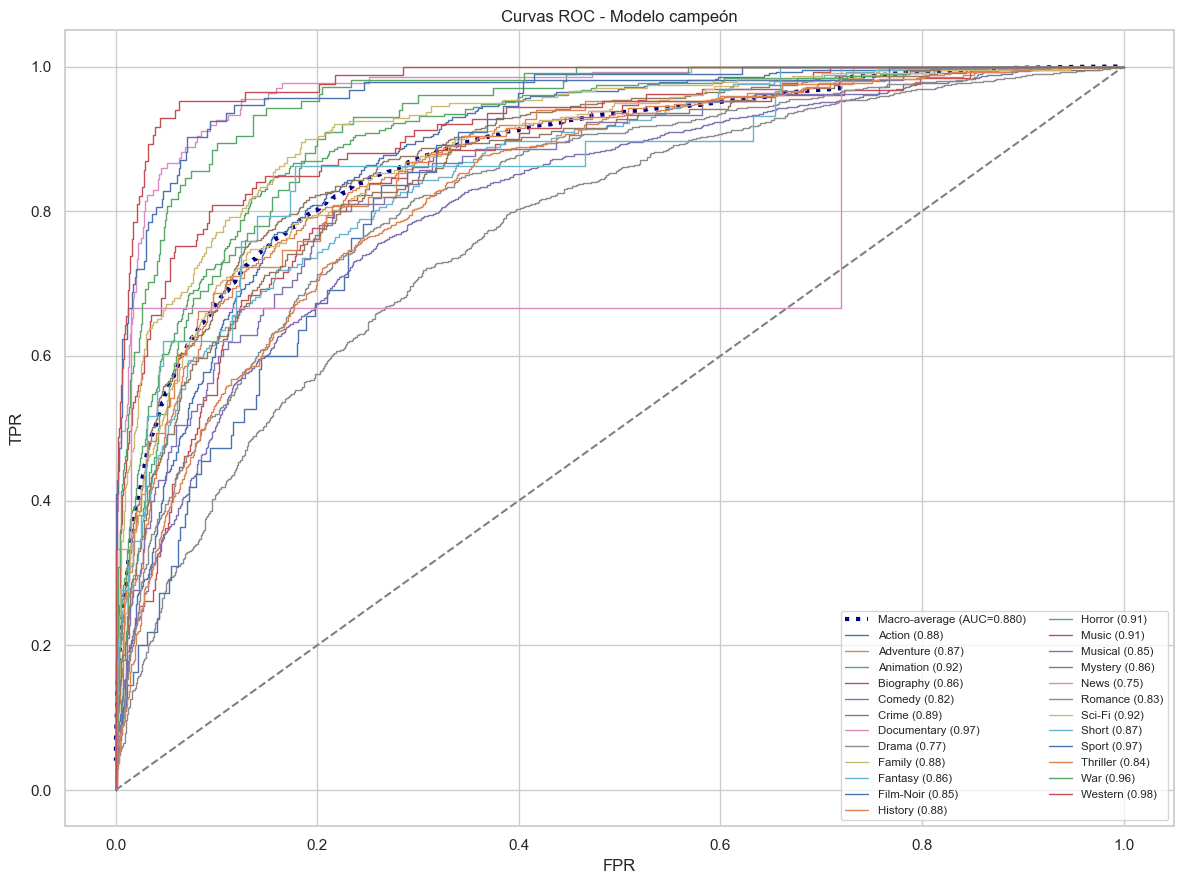

In [11]:
# Calcular AUC individual para cada uno de los 24 géneros
fpr_d, tpr_d, auc_d = {}, {}, {}
n = y_pred.shape[1]

for i in range(n):
    fpr_d[i], tpr_d[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    auc_d[i] = auc(fpr_d[i], tpr_d[i])

# Macro-average: interpolar y promediar todas las curvas
all_fpr   = np.unique(np.concatenate([fpr_d[i] for i in range(n)]))
mean_tpr  = sum(np.interp(all_fpr, fpr_d[i], tpr_d[i]) for i in range(n)) / n
auc_macro = auc(all_fpr, mean_tpr)

# Gráfico con curvas por clase + macro-average
plt.figure(figsize=(12, 9))
plt.plot(all_fpr, mean_tpr, 'navy', linestyle=':', lw=3,
         label=f'Macro-average (AUC={auc_macro:.3f})')
for i in range(n):
    plt.plot(fpr_d[i], tpr_d[i], lw=1,
             label=f'{mlb.classes_[i]} ({auc_d[i]:.2f})')
plt.plot([0,1],[0,1],'--',color='gray',lw=1.5)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curvas ROC - Modelo campeón')
plt.legend(loc='lower right', fontsize='x-small', ncol=2)
plt.tight_layout(); plt.show()

### 3. AUC por género

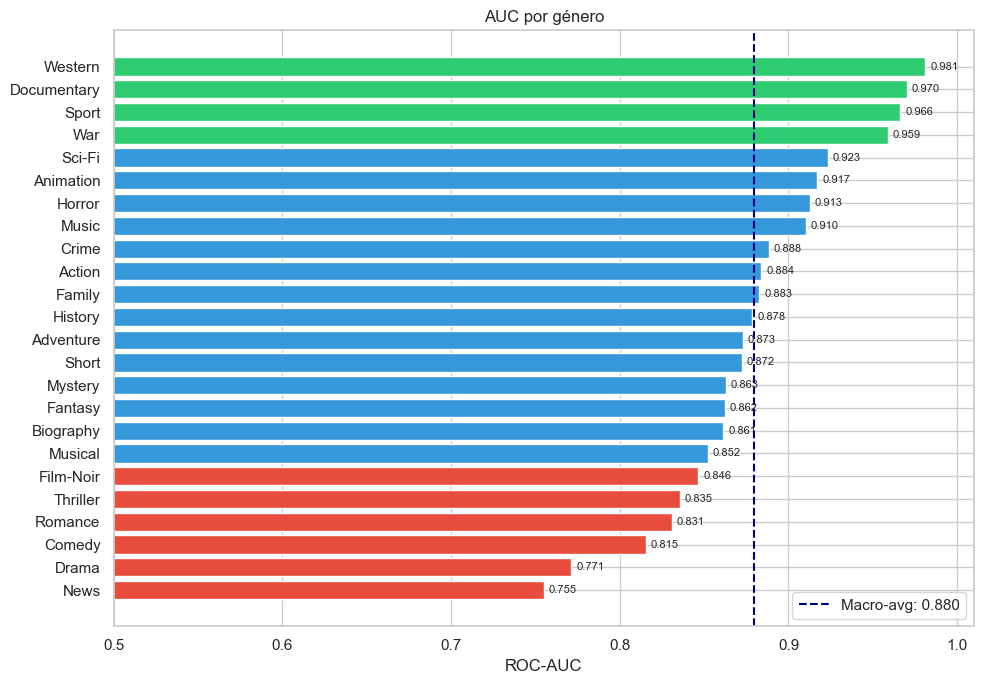

In [7]:
# Ordenar géneros por AUC para identificar los más y menos predecibles
auc_serie = pd.Series(
    {mlb.classes_[i]: auc_d[i] for i in range(n)}
).sort_values(ascending=True)

colors = ['#e74c3c' if v < 0.85 else '#2ecc71' if v > 0.95 else '#3498db'
          for v in auc_serie]

plt.figure(figsize=(10, 7))
bars = plt.barh(auc_serie.index, auc_serie.values, color=colors)
plt.axvline(auc_macro, color='navy', linestyle='--', lw=1.5,
            label=f'Macro-avg: {auc_macro:.3f}')
plt.xlabel('ROC-AUC')
plt.title('AUC por género')
plt.xlim(0.5, 1.01)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.003, bar.get_y() + bar.get_height()/2, f'{w:.3f}', va='center', fontsize=8)
plt.legend(); plt.tight_layout(); plt.show()

**Interpretación por género:**

Los géneros con AUC más alto tienen vocabulario altamente característico que no se superpone con otros. Western tiene "sheriff", "outlaw", "frontier"; Animation tiene "animated", "cartoon", "voice"; Documentary suele anunciarse explícitamente en su propia sinopsis.

Los géneros con AUC más bajo tienen el problema opuesto: su vocabulario se solapa con el de otros géneros. Film-Noir comparte léxico oscuro con Thriller y Crime, pero su distinción es tonal y visual, no léxica. Short define el formato, no el contenido narrativo, por lo que no existe vocabulario característico que el modelo pueda aprender. Para estos géneros, TF-IDF tiene un techo estructural que solo rompen los modelos contextuales como BERT o RoBERTa.

### 4. Inferencia — nuevas sinopsis

In [8]:
def predecir_generos(sinopsis, top_n=5):
    # Aplicar el mismo pipeline de preprocesamiento al texto nuevo
    texto = lemmatize_text(remove_stopwords(remove_tags(sinopsis)))
    X_new = tfidf.transform([texto])
    probs = clf.predict_proba(X_new)[0]
    resultado = pd.DataFrame({'genero': mlb.classes_, 'probabilidad': probs})
    return resultado.sort_values('probabilidad', ascending=False).head(top_n).reset_index(drop=True)

# Ejemplo 1: thriller de ciencia ficción
sinopsis_1 = """
A rogue scientist discovers the government has been secretly experimenting with alien DNA,
turning soldiers into unstoppable killers. Racing against time, she must expose the
conspiracy before the next test subject is unleashed.
"""
print('Thriller / Sci-Fi:')
print(predecir_generos(sinopsis_1).to_string(index=False))

Thriller / Sci-Fi:
  genero  probabilidad
  Sci-Fi      0.546211
Thriller      0.491194
  Action      0.356156
  Horror      0.235785
   Drama      0.193178


In [10]:
# Generar predicciones sobre el set de test completo y guardar
X_final    = tfidf.transform(dataTesting['plot'])
y_pred_fin = clf.predict_proba(X_final)

submission = pd.DataFrame(y_pred_fin, index=dataTesting.index, columns=cols)
submission.to_csv('data/predicciones_finales.csv', index_label='ID')

print(f'Predicciones guardadas: {submission.shape}')
submission.head(3)

Predicciones guardadas: (3383, 24)


,p_Action,p_Adventure,p_Animation,p_Biography,p_Comedy,p_Crime,p_Documentary,p_Drama,p_Family,p_Fantasy,...,p_Musical,p_Mystery,p_News,p_Romance,p_Sci-Fi,p_Short,p_Sport,p_Thriller,p_War,p_Western
1,0.119255,0.082546,0.024014,0.038449,0.356040,0.132933,0.034641,0.610124,0.048143,0.102422,...,0.036447,0.083494,0.001909,0.539351,0.058572,0.012871,0.025878,0.192105,0.028835,0.029604
4,0.167319,0.053528,0.028863,0.135003,0.292620,0.320251,0.058577,0.726176,0.038079,0.031579,...,0.032548,0.049682,0.001962,0.080523,0.034359,0.012531,0.029004,0.262276,0.048399,0.029550
5,0.113390,0.049495,0.018660,0.048298,0.184588,0.568868,0.034499,0.743533,0.032110,0.036123,...,0.022142,0.323557,0.001871,0.144701,0.076788,0.010646,0.022631,0.501991,0.033143,0.025034


### 5. Conclusiones

- **TF-IDF + Regresión Logística gana porque el problema es lineal.** El espacio TF-IDF es disperso y de alta dimensión, exactamente la geometría que LR explota sin necesidad de estructuras más complejas. Los modelos de árboles y redes neuronales no aportan nada en este contexto.

- **Los trigramas son la decisión que más sube el AUC.** Capturan frases como "serial killer" u "outer space" que los unigramas rompen en tokens sin sentido. El salto de unigramas a trigramas representa la mayor ganancia individual de todo el experimento.

- **GloVe no supera TF-IDF en sinopsis cortas.** El vocabulario temático es específico y el matching léxico exacto es más preciso que la generalización semántica de los embeddings. En corpus pequeños con dominio acotado, TF-IDF es más robusto.

- **Los géneros minoritarios son el reto real.** News, Film-Noir y Short tienen AUC más bajo por falta de ejemplos, vocabulario solapado o porque definen el formato y no el contenido. Para ellos, TF-IDF tiene un techo estructural.

- **El umbral de decisión importa más de lo que parece.** En multi-etiqueta desbalanceada, 0.5 raramente es el umbral óptimo. Un umbral más bajo mejora el recall de las clases raras a costa de algo de precisión en las mayoritarias.

- **El siguiente paso natural es un transformer.** Fine-tuning de DistilBERT o RoBERTa capturaría tono narrativo y matices que TF-IDF no puede. La pregunta es si 7.900 películas son suficientes para un fine-tuning efectivo.